# Before-Augmentation Baseline Fault Classification

This notebook trains the follwoing models on the 20260707-20260710 data before applying data augmentation:

- Random Forest
- Gradient Boosting
- SVM
-LSTM-AE

Data range:

20260707-20260710 

Goal: classify `Alarm_Code` using the available PLC process signals before augmentation.

## 1. Imports

In [23]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

In [24]:
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "alarm_event_analysis_outputs" / "time_gap_analysis" / "full_time_gap_report_clean.csv"
OUTPUT_DIR = BASE_DIR / "alarm_event_analysis_outputs" / "baseline_models_before_augmentation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Main split: train on July 8 and July 9, test on July 10.
TRAIN_DATES = ["2026-07-08", "2026-07-09"]
TEST_DATE = "2026-07-10"

# Use None to train RF/GB on all July 8-9 training rows. Use an integer for a stratified training sample.
MAX_TRAIN_ROWS_FOR_RF_GB = None

# Use all July 8-9 training rows for SVM by default.
# If RBF/kernel SVM is too slow, uncomment the next line and choose a practical cap, e.g. 50_000.
SVM_MAX_TRAIN_ROWS = None
# SVM_MAX_TRAIN_ROWS = 50_000

N_SPLITS_CV = 5

print(DATA_PATH)
print(OUTPUT_DIR)


d:\CODE\Weaving_Project\spectogram_analysis_4\20260706_to_20260709\alarm_event_analysis_outputs\time_gap_analysis\full_time_gap_report_clean.csv
d:\CODE\Weaving_Project\spectogram_analysis_4\20260706_to_20260709\alarm_event_analysis_outputs\baseline_models_before_augmentation


## 3. Load Dataset

In [25]:
df = pd.read_csv(DATA_PATH)
df["logged_at"] = pd.to_datetime(df["logged_at"], errors="coerce", format="mixed")

if df["logged_at"].isna().any():
    bad_rows = int(df["logged_at"].isna().sum())
    raise ValueError(f"{bad_rows} logged_at values could not be parsed as datetimes.")

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Date range: {df['logged_at'].min()} to {df['logged_at'].max()}")
display(df.head())
display(df.dtypes.to_frame("dtype").head(40))


Rows: 2,565,389
Columns: 37
Date range: 2026-07-08 00:00:00.080000 to 2026-07-10 23:59:59.902000


,dataset_id,excel_row_number,logged_at,previous_logged_at,time_gap_seconds,previous_dataset_id,previous_excel_row_number,Infeed_Speed_SV,Infeed_Speed_PV,INFEED_TORQUE,...,Single_Speed_SV,SINGLE_LIMIT_TRQ,Weaving_Run,Alarm_Code,Temperature_PV,Humidity_PV,tag27,tag28,tag29,tag30
0,1,2,2026-07-08 00:00:00.080,NaN,NaN,NaN,NaN,0.19,0.19,3.7,...,1.0,15.0,300,0,31.7,64.2,NaN,NaN,NaN,NaN
1,2,3,2026-07-08 00:00:00.182,2026-07-08 00:00:00.080,0.102,1.0,2.0,0.19,0.19,3.7,...,1.0,15.0,300,0,31.7,64.2,NaN,NaN,NaN,NaN
2,3,4,2026-07-08 00:00:00.284,2026-07-08 00:00:00.182,0.102,2.0,3.0,0.19,0.19,3.7,...,1.0,15.0,300,0,31.7,64.2,NaN,NaN,NaN,NaN
3,4,5,2026-07-08 00:00:00.389,2026-07-08 00:00:00.284,0.105,3.0,4.0,0.19,0.19,3.7,...,1.0,15.0,300,0,31.7,64.2,NaN,NaN,NaN,NaN
4,5,6,2026-07-08 00:00:00.488,2026-07-08 00:00:00.389,0.099,4.0,5.0,0.19,0.19,2.5,...,1.0,15.0,300,0,31.7,64.2,NaN,NaN,NaN,NaN


,dtype
dataset_id,int64
excel_row_number,int64
logged_at,datetime64[us]
previous_logged_at,str
time_gap_seconds,float64
previous_dataset_id,float64
previous_excel_row_number,float64
Infeed_Speed_SV,float64
Infeed_Speed_PV,float64
INFEED_TORQUE,float64


## 4. Inspect Target Distribution

,rows,percent
Alarm_Code,,
0,2000751,77.990
2,99674,3.885
8,459558,17.914
10,5406,0.211


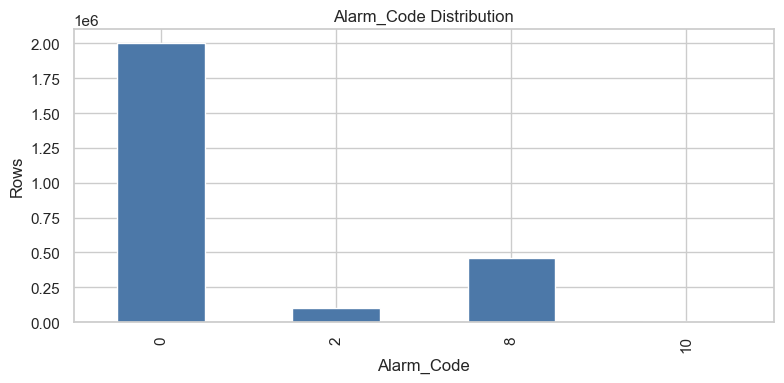

In [26]:
TARGET = "Alarm_Code"

target_counts = df[TARGET].value_counts(dropna=False).sort_index()
target_percent = (target_counts / len(df) * 100).round(3)
target_summary = pd.DataFrame({"rows": target_counts, "percent": target_percent})

display(target_summary)

ax = target_counts.plot(kind="bar", figsize=(8, 4), color="#4c78a8")
ax.set_title("Alarm_Code Distribution")
ax.set_xlabel("Alarm_Code")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.show()

## 5. Preprocessing: Remove Empty Columns, Constant Features, and Non-Signal Metadata

We remove:

- completely empty columns
- columns with only one unique non-empty value
- metadata/time/index columns that should not be used as sensor features
- previous-row helper columns such as `previous_logged_at`, `time_gap_seconds`, `previous_dataset_id`, and `previous_excel_row_number`
- `Alarm_Code` from features because it is the target

This keeps the model focused on PLC process signals rather than row identity, timestamps, or logging-gap artifacts.


In [27]:
metadata_cols = {
    "dataset_id",
    "excel_row_number",
    "logged_at",
    "previous_logged_at",
    "time_gap_seconds",
    "previous_dataset_id",
    "previous_excel_row_number",
    TARGET,
}

empty_cols = [col for col in df.columns if df[col].isna().all()]

candidate_cols = [col for col in df.columns if col not in metadata_cols and col not in empty_cols]

# Convert candidates to numeric where possible. Non-numeric columns become all NaN and will be removed.
X_all = df[candidate_cols].apply(pd.to_numeric, errors="coerce")

all_nan_after_numeric = [col for col in X_all.columns if X_all[col].isna().all()]
X_all = X_all.drop(columns=all_nan_after_numeric)

constant_cols = [col for col in X_all.columns if X_all[col].nunique(dropna=True) <= 1]
X_all = X_all.drop(columns=constant_cols)

y_all = pd.to_numeric(df[TARGET], errors="coerce").fillna(0).astype(int)

preprocess_report = {
    "original_rows": int(len(df)),
    "original_columns": int(df.shape[1]),
    "removed_metadata_columns": sorted([c for c in metadata_cols if c in df.columns]),
    "removed_empty_columns": empty_cols,
    "removed_non_numeric_columns": all_nan_after_numeric,
    "removed_constant_columns": constant_cols,
    "final_feature_count": int(X_all.shape[1]),
    "final_features": list(X_all.columns),
}

with open(OUTPUT_DIR / "preprocess_report_before_augmentation.json", "w", encoding="utf-8") as f:
    json.dump(preprocess_report, f, indent=2)

print(f"Final feature count: {X_all.shape[1]}")
print("Final features:")
for col in X_all.columns:
    print("-", col)

print("Removed metadata/helper columns:", sorted([c for c in metadata_cols if c in df.columns]))
print("Removed empty columns:", empty_cols)
print("Removed constant columns:", constant_cols)


Final feature count: 12
Final features:
- Infeed_Speed_SV
- Infeed_Speed_PV
- INFEED_TORQUE
- Loadcell_Weight_PV
- Dancer_Pressure_PV
- Dancer_Gyro_Position
- Weaving_Line_Speed
- Loadcell_PV
- Motor_RPM
- Weaving_Run
- Temperature_PV
- Humidity_PV
Removed metadata/helper columns: ['Alarm_Code', 'dataset_id', 'excel_row_number', 'logged_at', 'previous_dataset_id', 'previous_excel_row_number', 'previous_logged_at', 'time_gap_seconds']
Removed empty columns: ['tag27', 'tag28', 'tag29', 'tag30']
Removed constant columns: ['Loadcell_Weight_SV', 'Dancer_Pressure_SV', 'Dancer_Weight_SV', 'PID_P', 'PID_I', 'PID_D', 'PID_Limit', 'Speed_Limit', 'Infeed_Input_Scale', 'Loadcell_Deadzone', 'Loadcell_Allowtime', 'Single_Speed_SV', 'SINGLE_LIMIT_TRQ']


## 6. Optional Stratified Sampling for Training Only

The main evaluation is date/time-based:

- Train: July 8 and July 9
- Test: July 10

If the training set is too large, `MAX_TRAIN_ROWS_FOR_RF_GB` can reduce only the training rows using stratified sampling. The July 10 test set is not sampled by default, so it remains a future-date holdout.


In [28]:
def stratified_sample(X, y, max_rows, random_state=RANDOM_STATE):
    if max_rows is None or len(X) <= max_rows:
        return X.reset_index(drop=True), y.reset_index(drop=True)

    sample_frac = max_rows / len(X)
    sample_idx = (
        pd.DataFrame({"target": y})
        .groupby("target", group_keys=False)
        .apply(lambda g: g.sample(max(1, int(round(len(g) * sample_frac))), random_state=random_state))
        .index
    )
    return X.loc[sample_idx].reset_index(drop=True), y.loc[sample_idx].reset_index(drop=True)


def make_date_split():
    """Create the July 8-9 train / July 10 test split whenever needed."""
    required = ["df", "X_all", "y_all", "TRAIN_DATES", "TEST_DATE"]
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            "Missing required variables: " + ", ".join(missing) +
            ". Run the load and preprocessing cells first."
        )

    df["logged_at"] = pd.to_datetime(df["logged_at"], errors="coerce", format="mixed")
    if df["logged_at"].isna().any():
        bad_rows = int(df["logged_at"].isna().sum())
        raise ValueError(f"{bad_rows} logged_at values could not be parsed as datetimes.")

    row_dates = df["logged_at"].dt.strftime("%Y-%m-%d")
    train_mask = row_dates.isin(TRAIN_DATES)
    test_mask = row_dates.eq(TEST_DATE)

    if not train_mask.any():
        raise ValueError(f"No training rows found for TRAIN_DATES={TRAIN_DATES}")
    if not test_mask.any():
        raise ValueError(f"No test rows found for TEST_DATE={TEST_DATE}")

    X_train_full_local = X_all.loc[train_mask].reset_index(drop=True)
    y_train_full_local = y_all.loc[train_mask].reset_index(drop=True)
    X_test_local = X_all.loc[test_mask].reset_index(drop=True)
    y_test_local = y_all.loc[test_mask].reset_index(drop=True)
    X_train_local, y_train_local = stratified_sample(
        X_train_full_local, y_train_full_local, MAX_TRAIN_ROWS_FOR_RF_GB
    )

    return X_train_full_local, y_train_full_local, X_train_local, y_train_local, X_test_local, y_test_local


def ensure_date_split():
    """Populate split variables if they do not already exist."""
    global X_train_full, y_train_full, X_train, y_train, X_test, y_test
    if all(name in globals() for name in ["X_train_full", "y_train_full", "X_train", "y_train", "X_test", "y_test"]):
        return
    print("Date split variables were not found. Creating July 8-9 train / July 10 test split...")
    X_train_full, y_train_full, X_train, y_train, X_test, y_test = make_date_split()


In [29]:
rf_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestClassifier(
                n_estimators=70,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                class_weight="balanced_subsample",
            ),
        ),
    ]
)

gb_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=70,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

svm_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            SVC(
                kernel="rbf",
                gamma="scale",
                C=90,
                class_weight="balanced",
                cache_size=2000,
            ),
        ),
    ]
)

models = {
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "SVM RBF": svm_model,
}

In [30]:
X_train_full, y_train_full, X_train, y_train, X_test, y_test = make_date_split()

print("Date/time split")
print(f"Train dates: {TRAIN_DATES}")
print(f"Test date: {TEST_DATE}")
print(f"Full training rows: {len(X_train_full):,}")
print(f"Model training rows for RF/GB: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

print("Training target distribution:")
display(y_train.value_counts().sort_index().to_frame("train_rows"))

print("Test target distribution:")
display(y_test.value_counts().sort_index().to_frame("test_rows"))


Date/time split
Train dates: ['2026-07-08', '2026-07-09']
Test date: 2026-07-10
Full training rows: 1,710,166
Model training rows for RF/GB: 1,710,166
Test rows: 855,223
Training target distribution:


,train_rows
Alarm_Code,
0,1333180
2,65112
8,306468
10,5406


Test target distribution:


,test_rows
Alarm_Code,
0,667571
2,34562
8,153090


In [31]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    }

    print(pd.Series(metrics).drop("model"))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    labels = sorted(np.unique(np.concatenate([y_test.to_numpy(), y_pred])))
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=[f"actual_{x}" for x in labels], columns=[f"pred_{x}" for x in labels])

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return metrics, cm_df, model

## 10. Train and Evaluate Random Forest


===== Random Forest =====
accuracy              0.699509
precision_weighted    0.681728
recall_weighted       0.699509
f1_weighted           0.690467
precision_macro       0.365637
recall_macro          0.379101
f1_macro              0.372193
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.82    667571
           2       0.00      0.00      0.00     34562
           8       0.29      0.31      0.30    153090

    accuracy                           0.70    855223
   macro avg       0.37      0.38      0.37    855223
weighted avg       0.68      0.70      0.69    855223



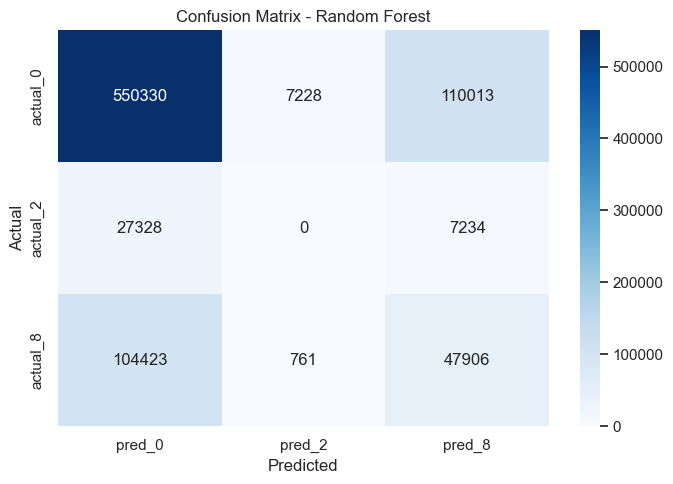

In [32]:
ensure_date_split()

rf_metrics, rf_cm, rf_fitted = evaluate_model(
    "Random Forest", rf_model, X_train, y_train, X_test, y_test
)

rf_cm.to_csv(OUTPUT_DIR / "confusion_matrix_random_forest_before_augmentation.csv")


## 11. Train and Evaluate Gradient Boosting


===== Gradient Boosting =====
accuracy              0.751081
precision_weighted    0.781556
recall_weighted       0.751081
f1_weighted           0.755007
precision_macro       0.444344
recall_macro           0.51652
f1_macro              0.463758
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84    667571
           2       0.00      0.00      0.00     34562
           8       0.43      0.76      0.55    153090

    accuracy                           0.75    855223
   macro avg       0.44      0.52      0.46    855223
weighted avg       0.78      0.75      0.76    855223



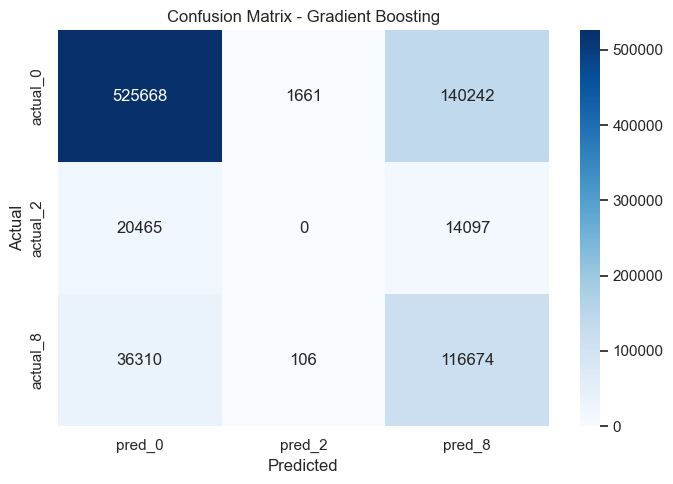

In [33]:
ensure_date_split()

gb_metrics, gb_cm, gb_fitted = evaluate_model(
    "Gradient Boosting", gb_model, X_train, y_train, X_test, y_test
)

gb_cm.to_csv(OUTPUT_DIR / "confusion_matrix_gradient_boosting_before_augmentation.csv")

## 12 Train and Evaluate SVM

In [34]:
if "X_train_full" not in globals() or "y_train_full" not in globals() or "X_test" not in globals() or "y_test" not in globals():
    print("Date split variables were not found. Recreating train/test split from logged_at...")
    df["logged_at"] = pd.to_datetime(df["logged_at"], errors="coerce", format="mixed")
    if df["logged_at"].isna().any():
        bad_rows = int(df["logged_at"].isna().sum())
        raise ValueError(f"{bad_rows} logged_at values could not be parsed as datetimes.")

    row_dates = df["logged_at"].dt.strftime("%Y-%m-%d")
    train_mask = row_dates.isin(TRAIN_DATES)
    test_mask = row_dates.eq(TEST_DATE)

    X_train_full = X_all.loc[train_mask].reset_index(drop=True)
    y_train_full = y_all.loc[train_mask].reset_index(drop=True)
    X_test = X_all.loc[test_mask].reset_index(drop=True)
    y_test = y_all.loc[test_mask].reset_index(drop=True)

ensure_date_split()

X_svm_train, y_svm_train = stratified_sample(X_train_full, y_train_full, SVM_MAX_TRAIN_ROWS)
X_svm_test, y_svm_test = X_test, y_test

print(f"SVM training rows: {len(X_svm_train):,}")
print(f"SVM test rows: {len(X_svm_test):,}")
print("SVM training target distribution:")
display(y_svm_train.value_counts().sort_index().to_frame("train_rows"))
print("SVM test target distribution:")
display(y_svm_test.value_counts().sort_index().to_frame("test_rows"))


SVM training rows: 1,710,166
SVM test rows: 855,223
SVM training target distribution:


,train_rows
Alarm_Code,
0,1333180
2,65112
8,306468
10,5406


SVM test target distribution:


,test_rows
Alarm_Code,
0,667571
2,34562
8,153090



===== SVM =====
accuracy              0.450083
precision_weighted    0.629861
recall_weighted       0.450083
f1_weighted           0.507036
precision_macro       0.334578
recall_macro           0.32903
f1_macro              0.304421
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.75      0.47      0.58    667571
           2       0.01      0.05      0.02     34562
           8       0.24      0.47      0.32    153090

    accuracy                           0.45    855223
   macro avg       0.33      0.33      0.30    855223
weighted avg       0.63      0.45      0.51    855223



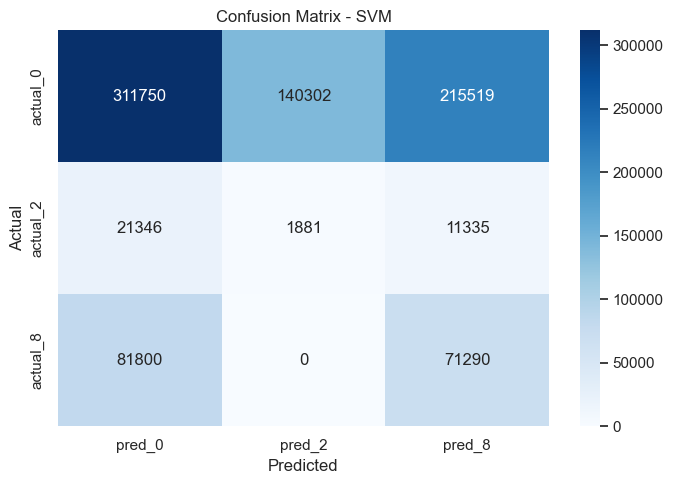

In [35]:
svm_metrics, svm_cm, svm_fitted = evaluate_model(
    "SVM", svm_model, X_svm_train, y_svm_train, X_svm_test, y_svm_test
)

svm_cm.to_csv(OUTPUT_DIR / "confusion_matrix_svm_before_augmentation.csv")

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro
0,Random Forest,0.699509,0.681728,0.699509,0.690467,0.365637,0.379101,0.372193
1,Gradient Boosting,0.751081,0.781556,0.751081,0.755007,0.444344,0.516520,0.463758
2,SVM,0.450083,0.629861,0.450083,0.507036,0.334578,0.329030,0.304421


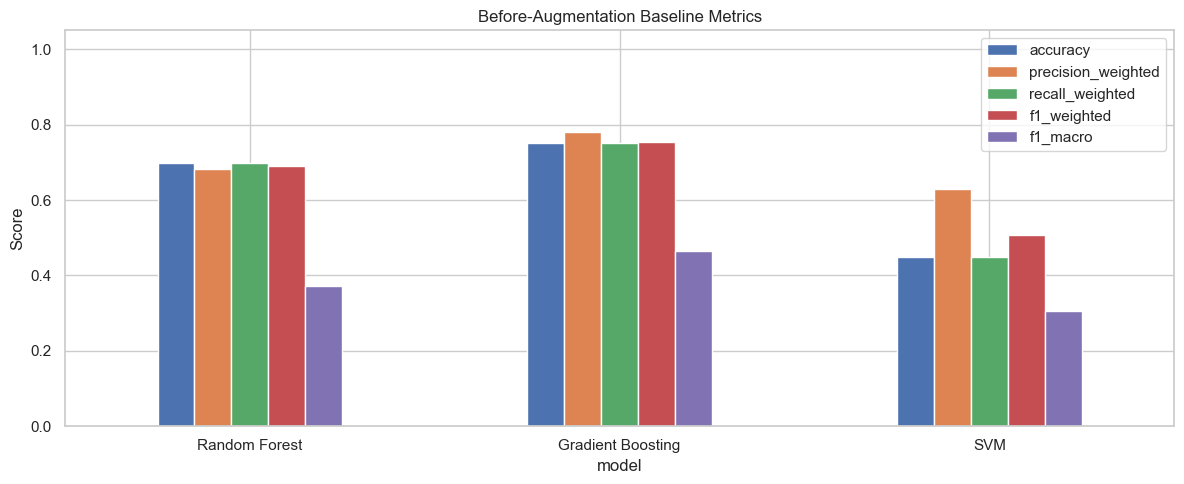

In [36]:
metrics_df = pd.DataFrame([rf_metrics, gb_metrics, svm_metrics])
display(metrics_df)

metrics_df.to_csv(OUTPUT_DIR / "baseline_metrics_before_augmentation.csv", index=False)

plot_cols = ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted", "f1_macro"]
metrics_df.set_index("model")[plot_cols].plot(kind="bar", figsize=(12, 5))
plt.title("Before-Augmentation Baseline Metrics")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 15. 5-Fold Cross-Validation on Training Dates Only

Cmputed only on the July 8-9 training period. The main result should still be the held-out July 10 test performance.

If this is too slow, reduce `MAX_TRAIN_ROWS_FOR_RF_GB` or `SVM_MAX_TRAIN_ROWS` in the configuration cell.


In [37]:
scoring = {
    "accuracy": "accuracy",
    "precision_weighted": "precision_weighted",
    "recall_weighted": "recall_weighted",
    "f1_weighted": "f1_weighted",
    "f1_macro": "f1_macro",
}

cv = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=False)

cv_results = []

for name, model, X_cv, y_cv in [
    ("Random Forest", rf_model, X_train, y_train),
    ("Gradient Boosting", gb_model, X_train, y_train),
    ("SVM", svm_model, X_svm_train, y_svm_train),
]:
    print(f"Running CV for {name} on July 8-9 training rows only: {len(X_cv):,} rows")
    scores = cross_validate(model, X_cv, y_cv, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"model": name}
    for metric_name in scoring:
        values = scores[f"test_{metric_name}"]
        row[f"{metric_name}_mean"] = values.mean()
        row[f"{metric_name}_std"] = values.std()
    cv_results.append(row)

cv_df = pd.DataFrame(cv_results)
display(cv_df)
cv_df.to_csv(OUTPUT_DIR / "baseline_5fold_cv_training_dates_before_augmentation.csv", index=False)


Running CV for Random Forest on July 8-9 training rows only: 1,710,166 rows
Running CV for Gradient Boosting on July 8-9 training rows only: 1,710,166 rows
Running CV for SVM on July 8-9 training rows only: 1,710,166 rows


,model,accuracy_mean,accuracy_std,precision_weighted_mean,precision_weighted_std,recall_weighted_mean,recall_weighted_std,f1_weighted_mean,f1_weighted_std,f1_macro_mean,f1_macro_std
0,Random Forest,0.728984,0.214116,0.850688,0.078607,0.728984,0.214116,0.751429,0.200707,0.487277,0.142994
1,Gradient Boosting,0.713152,0.189698,0.852066,0.073155,0.713152,0.189698,0.749110,0.165754,0.479210,0.147930
2,SVM,0.681914,0.205931,0.829852,0.082590,0.681914,0.205931,0.716133,0.189807,0.451366,0.120004


## 16. Feature Importance for Tree Models

This helps identify which PLC signals the baseline models rely on before augmentation.

,feature,importance
11,Humidity_PV,0.388275
10,Temperature_PV,0.180337
7,Loadcell_PV,0.080144
3,Loadcell_Weight_PV,0.079707
2,INFEED_TORQUE,0.056870
9,Weaving_Run,0.048836
8,Motor_RPM,0.041664
0,Infeed_Speed_SV,0.039041
6,Weaving_Line_Speed,0.035364
1,Infeed_Speed_PV,0.034774


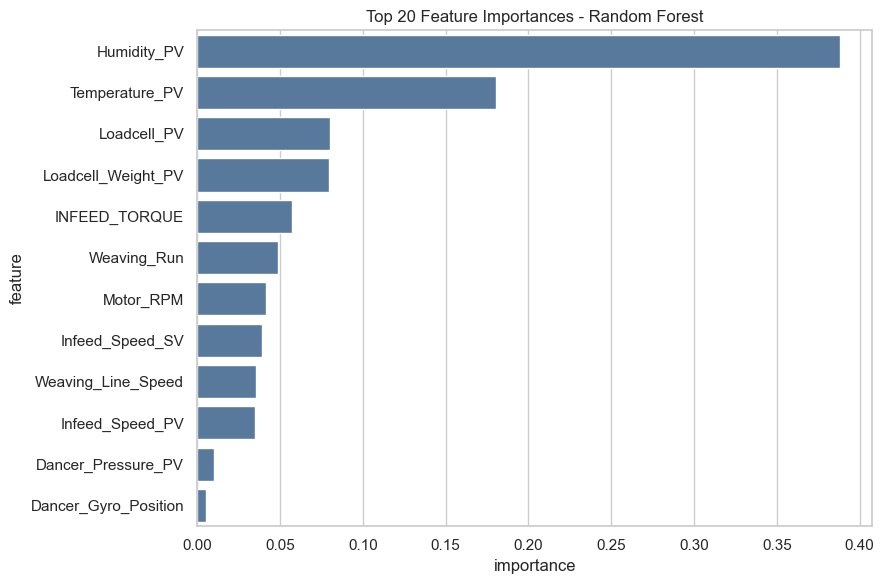

,feature,importance
11,Humidity_PV,0.719308
10,Temperature_PV,0.151584
2,INFEED_TORQUE,0.030433
3,Loadcell_Weight_PV,0.028093
7,Loadcell_PV,0.026053
9,Weaving_Run,0.018648
8,Motor_RPM,0.012244
6,Weaving_Line_Speed,0.009687
0,Infeed_Speed_SV,0.003111
1,Infeed_Speed_PV,0.000712


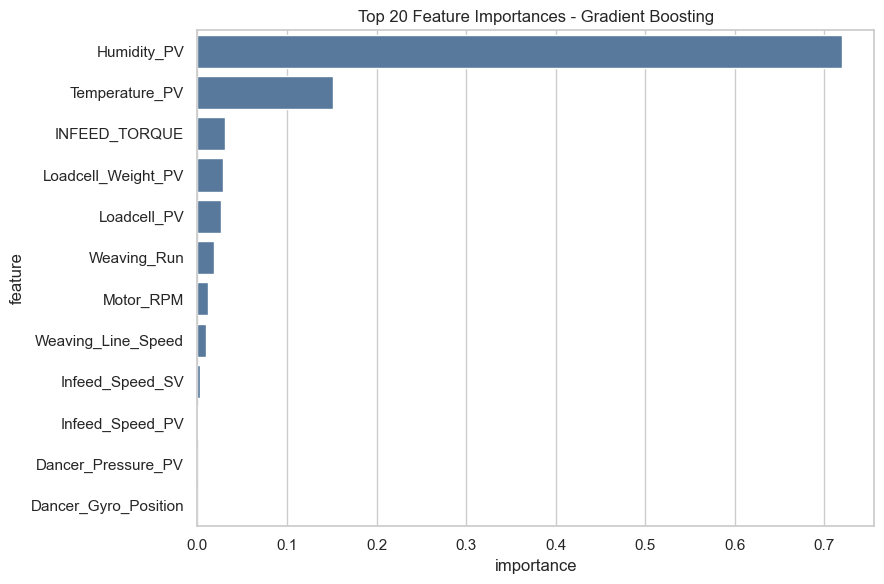

In [38]:
def plot_feature_importance(fitted_pipeline, model_name, top_n=20):
    model = fitted_pipeline.named_steps["model"]
    if not hasattr(model, "feature_importances_"):
        print(f"{model_name} has no feature_importances_ attribute.")
        return None

    importance = pd.DataFrame(
        {"feature": X_all.columns, "importance": model.feature_importances_}
    ).sort_values("importance", ascending=False)

    display(importance.head(top_n))
    importance.to_csv(OUTPUT_DIR / f"feature_importance_{model_name.lower().replace(' ', '_')}_before_augmentation.csv", index=False)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=importance.head(top_n), y="feature", x="importance", color="#4c78a8")
    plt.title(f"Top {top_n} Feature Importances - {model_name}")
    plt.tight_layout()
    plt.show()

    return importance

rf_importance = plot_feature_importance(rf_fitted, "Random Forest")
gb_importance = plot_feature_importance(gb_fitted, "Gradient Boosting")

## 17. LSTM Autoencoder Baseline Before Augmentation

The paper also uses an LSTM Autoencoder for anomaly detection. This is different from RF/GB/SVM classification:

- RF/GB/SVM predict `Alarm_Code` classes directly.
- LSTM-AE learns to reconstruct normal sequences.
- A sequence is flagged as anomalous when reconstruction error exceeds a threshold.

Architecture used from the paper:

- Input: `(seq_length, n_features)`
- LSTM Encoder: `128` units, ReLU, returns sequence
- RepeatVector: repeats latent representation across sequence length
- LSTM Decoder: `128` units, ReLU, returns sequence
- Dense: `n_features`

Training setup here:

- Train on normal sequences from July 8-9 only (`Alarm_Code = 0`).
- Test on July 10 sequences.
- Sequence label is binary: `0 = all rows normal`, `1 = one or more alarm rows in the sequence`.
- Threshold is the 95th percentile of training reconstruction error


In [39]:
# LSTM-AE configuration
LSTM_SEQUENCE_LENGTH = 100
LSTM_SEQUENCE_STEP = 10
LSTM_MAX_NORMAL_TRAIN_SEQUENCES = 20_000
LSTM_MAX_TEST_SEQUENCES = 50_000
LSTM_EPOCHS = 10
LSTM_BATCH_SIZE = 256
LSTM_THRESHOLD_PERCENTILE = 95

print("LSTM sequence length:", LSTM_SEQUENCE_LENGTH)
print("LSTM sequence step:", LSTM_SEQUENCE_STEP)
print("Max normal train sequences:", LSTM_MAX_NORMAL_TRAIN_SEQUENCES)
print("Max test sequences:", LSTM_MAX_TEST_SEQUENCES)


LSTM sequence length: 100
LSTM sequence step: 10
Max normal train sequences: 20000
Max test sequences: 50000


In [40]:
try:
    import tensorflow as tf
    from tensorflow.keras.layers import Dense, Input, LSTM, RepeatVector, TimeDistributed
    from tensorflow.keras.models import Model
    from tensorflow.keras.callbacks import EarlyStopping
    from sklearn.preprocessing import MinMaxScaler
except ImportError as exc:
    raise ImportError(
        "TensorFlow is required for the LSTM-AE section. "
        "Install it in the .weaving environment before running this section."
    ) from exc

print("TensorFlow version:", tf.__version__)
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


ImportError: TensorFlow is required for the LSTM-AE section. Install it in the .weaving environment before running this section.

In [ ]:
ensure_date_split()

# Fit scaler on July 8-9 training rows only to avoid test-day leakage.
scaler = MinMaxScaler()
X_train_scaled_full = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

y_train_binary_full = (y_train_full != 0).astype(int).to_numpy()
y_test_binary = (y_test != 0).astype(int).to_numpy()

print("Training rows for sequence source:", X_train_scaled_full.shape)
print("Test rows for sequence source:", X_test_scaled.shape)
print("Feature count:", X_train_scaled_full.shape[1])


In [ ]:
def make_sequences(X, y_binary, seq_length, step):
    """Create fixed-length sequences and binary labels from continuous time-ordered rows."""
    X = np.asarray(X, dtype=np.float32)
    y_binary = np.asarray(y_binary, dtype=np.int8)
    if len(X) < seq_length:
        return np.empty((0, seq_length, X.shape[1]), dtype=np.float32), np.empty((0,), dtype=np.int8), np.empty((0,), dtype=int)

    sequences = []
    labels = []
    start_indices = []
    for start in range(0, len(X) - seq_length + 1, step):
        end = start + seq_length
        sequences.append(X[start:end])
        labels.append(int(y_binary[start:end].max()))
        start_indices.append(start)

    return np.stack(sequences), np.asarray(labels, dtype=np.int8), np.asarray(start_indices, dtype=int)

X_train_seq_all, y_train_seq_all, train_start_idx = make_sequences(
    X_train_scaled_full,
    y_train_binary_full,
    LSTM_SEQUENCE_LENGTH,
    LSTM_SEQUENCE_STEP,
)
X_test_seq, y_test_seq, test_start_idx = make_sequences(
    X_test_scaled,
    y_test_binary,
    LSTM_SEQUENCE_LENGTH,
    LSTM_SEQUENCE_STEP,
)

# Autoencoder trains only on fully normal sequences from July 8-9.
normal_train_mask = y_train_seq_all == 0
X_lstm_train = X_train_seq_all[normal_train_mask]

if len(X_lstm_train) > LSTM_MAX_NORMAL_TRAIN_SEQUENCES:
    rng = np.random.default_rng(RANDOM_STATE)
    selected = rng.choice(len(X_lstm_train), size=LSTM_MAX_NORMAL_TRAIN_SEQUENCES, replace=False)
    X_lstm_train = X_lstm_train[selected]

if len(X_test_seq) > LSTM_MAX_TEST_SEQUENCES:
    rng = np.random.default_rng(RANDOM_STATE)
    selected = np.sort(rng.choice(len(X_test_seq), size=LSTM_MAX_TEST_SEQUENCES, replace=False))
    X_test_seq_eval = X_test_seq[selected]
    y_test_seq_eval = y_test_seq[selected]
    test_start_idx_eval = test_start_idx[selected]
else:
    X_test_seq_eval = X_test_seq
    y_test_seq_eval = y_test_seq
    test_start_idx_eval = test_start_idx

print(f"All train sequences: {len(X_train_seq_all):,}")
print(f"Normal train sequences used by LSTM-AE: {len(X_lstm_train):,}")
print(f"All test sequences: {len(X_test_seq):,}")
print(f"Test sequences evaluated: {len(X_test_seq_eval):,}")
print("Test sequence label distribution:")
display(pd.Series(y_test_seq_eval).value_counts().sort_index().rename(index={0:"normal", 1:"alarm"}).to_frame("sequences"))


In [ ]:
seq_length = LSTM_SEQUENCE_LENGTH
n_features = X_lstm_train.shape[2]

inputs = Input(shape=(seq_length, n_features))
encoded_sequence = LSTM(128, activation="relu", return_sequences=True)(inputs)
encoded_vector = LSTM(128, activation="relu", return_sequences=False)(encoded_sequence)
repeated = RepeatVector(seq_length)(encoded_vector)
decoded = LSTM(128, activation="relu", return_sequences=True)(repeated)
outputs = TimeDistributed(Dense(n_features))(decoded)

lstm_ae = Model(inputs, outputs, name="lstm_autoencoder_before_augmentation")
lstm_ae.compile(optimizer="adam", loss="mse")
lstm_ae.summary()


In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

history = lstm_ae.fit(
    X_lstm_train,
    X_lstm_train,
    epochs=LSTM_EPOCHS,
    batch_size=LSTM_BATCH_SIZE,
    validation_split=0.2,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1,
)

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("LSTM-AE Training Loss Before Augmentation")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
def reconstruction_error(model, X_seq, batch_size=LSTM_BATCH_SIZE):
    reconstructed = model.predict(X_seq, batch_size=batch_size, verbose=0)
    return np.mean(np.square(X_seq - reconstructed), axis=(1, 2))

train_errors = reconstruction_error(lstm_ae, X_lstm_train)
threshold = np.percentile(train_errors, LSTM_THRESHOLD_PERCENTILE)

test_errors = reconstruction_error(lstm_ae, X_test_seq_eval)
y_lstm_pred = (test_errors > threshold).astype(int)

print(f"Reconstruction threshold ({LSTM_THRESHOLD_PERCENTILE}th percentile): {threshold:.8f}")
print("
LSTM-AE binary anomaly metrics on July 10 sequences:")
print("Accuracy:", accuracy_score(y_test_seq_eval, y_lstm_pred))
print("Precision:", precision_score(y_test_seq_eval, y_lstm_pred, zero_division=0))
print("Recall:", recall_score(y_test_seq_eval, y_lstm_pred, zero_division=0))
print("F1:", f1_score(y_test_seq_eval, y_lstm_pred, zero_division=0))
print("
Classification report:")
print(classification_report(y_test_seq_eval, y_lstm_pred, target_names=["normal", "alarm"], zero_division=0))

lstm_cm = confusion_matrix(y_test_seq_eval, y_lstm_pred, labels=[0, 1])
lstm_cm_df = pd.DataFrame(lstm_cm, index=["actual_normal", "actual_alarm"], columns=["pred_normal", "pred_alarm"])
display(lstm_cm_df)

plt.figure(figsize=(6, 4))
sns.heatmap(lstm_cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - LSTM-AE Before Augmentation")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(train_errors, bins=50, alpha=0.7, label="normal train reconstruction error")
plt.axvline(threshold, color="red", linestyle="--", label=f"{LSTM_THRESHOLD_PERCENTILE}th percentile threshold")
plt.title("LSTM-AE Reconstruction Error Threshold")
plt.xlabel("MSE reconstruction error")
plt.ylabel("Sequence count")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(test_errors, linewidth=0.8, label="July 10 reconstruction error")
plt.axhline(threshold, color="red", linestyle="--", label="threshold")
plt.scatter(
    np.where(y_lstm_pred == 1)[0],
    test_errors[y_lstm_pred == 1],
    s=8,
    color="red",
    label="predicted anomaly",
    alpha=0.7,
)
plt.title("LSTM-AE Reconstruction Error on July 10 Test Sequences")
plt.xlabel("Evaluated sequence index")
plt.ylabel("MSE reconstruction error")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
lstm_metrics = {
    "model": "LSTM Autoencoder",
    "task": "binary anomaly detection",
    "train_dates": ",".join(TRAIN_DATES),
    "test_date": TEST_DATE,
    "sequence_length": LSTM_SEQUENCE_LENGTH,
    "sequence_step": LSTM_SEQUENCE_STEP,
    "normal_train_sequences": int(len(X_lstm_train)),
    "test_sequences": int(len(X_test_seq_eval)),
    "threshold_percentile": LSTM_THRESHOLD_PERCENTILE,
    "threshold": float(threshold),
    "accuracy": accuracy_score(y_test_seq_eval, y_lstm_pred),
    "precision": precision_score(y_test_seq_eval, y_lstm_pred, zero_division=0),
    "recall": recall_score(y_test_seq_eval, y_lstm_pred, zero_division=0),
    "f1": f1_score(y_test_seq_eval, y_lstm_pred, zero_division=0),
}

lstm_metrics_df = pd.DataFrame([lstm_metrics])
display(lstm_metrics_df)
lstm_metrics_df.to_csv(OUTPUT_DIR / "lstm_autoencoder_metrics_before_augmentation.csv", index=False)
lstm_cm_df.to_csv(OUTPUT_DIR / "confusion_matrix_lstm_autoencoder_before_augmentation.csv")

error_df = pd.DataFrame({
    "test_sequence_start_index": test_start_idx_eval,
    "true_binary_alarm_sequence": y_test_seq_eval,
    "reconstruction_error": test_errors,
    "predicted_anomaly": y_lstm_pred,
})
error_df.to_csv(OUTPUT_DIR / "lstm_autoencoder_reconstruction_errors_before_augmentation.csv", index=False)


## 18. Notes for the Next Step: Augmentation

After this baseline is complete, the next notebook should create augmented training windows only from the July 8-9 training set, then retrain the same models and evaluate on the unchanged July 10 test set.

Important: augmentation should not be applied before the date split, because that would leak synthetic versions of future test-day behavior into training.
